# Gating Strategy Visualizations (derived_8.2)

This notebook contains detailed visualizations for the top 3 gating strategies for $K=2$ and $K=3$ on the `derived_8.2` soil moisture dataset. We analyze target separation, feature-target correlation drift, feature-space cluster boundaries, and the spatial distribution of the gating groups across Washington state.


## 1. Imports and Custom Plot Styling

We import the necessary packages and configure matplotlib/seaborn to produce premium-quality, high-DPI plots. We use customized color palettes for visual appeal.

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Set style for premium aesthetics using standard matplotlib
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 16,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--'
})

# Custom premium color palettes
PALETTE_K2 = ["#6B9AC4", "#E07B39"]  # Muted Blue and Burnt Orange
PALETTE_K3 = ["#4A90E2", "#F5A623", "#7ED321"]  # Bright Blue, Amber, and Apple Green
PALETTE_DIVERGING = "RdBu_r"  # Reverse RdBu so red means positive correlation and blue means negative

print("Libraries imported successfully and plot settings initialized.")

Libraries imported successfully and plot settings initialized.


## 2. Load and Clean Dataset

We load the `train.csv`, `val.csv`, and `station_static_features.csv` files, merge them, and extract date features (month and season). We also import `OVERALL_SELECTED_FEATURES_V3` to restrict analysis to valid features.

In [2]:
# Define paths
TRAIN_PATH = "../../../data/splits/derived_8.2/train.csv"
VAL_PATH = "../../../data/splits/derived_8.2/val.csv"
STATIC_PATH = "../../../data/splits/derived_8.2/station_static_features.csv"

# Load datasets
train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
static_df = pd.read_csv(STATIC_PATH)

# Add month and season features to train and val
def add_date_features(df):
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])
    df['month'] = df['date'].dt.month
    
    # Season mapping
    # Dry: July, August, September (7, 8, 9)
    # Wet: November, December, January, February, March (11, 12, 1, 2, 3)
    # Transition: April, May, June, October (4, 5, 6, 10)
    conditions = [
        df['month'].isin([7, 8, 9]),
        df['month'].isin([11, 12, 1, 2, 3]),
        df['month'].isin([4, 5, 6, 10])
    ]
    choices = ['Dry_Season', 'Wet_Season', 'Transition_Season']
    df['season'] = np.select(conditions, choices, default='Transition_Season')
    return df

train_df = add_date_features(train_df)
val_df = add_date_features(val_df)

# Merge static features based on station_id if not already merged
static_cols_to_merge = [c for c in static_df.columns if c not in train_df.columns or c == 'station_id']
if len(static_cols_to_merge) > 1:
    train_df = train_df.merge(static_df[static_cols_to_merge], on='station_id', how='left')
    val_df = val_df.merge(static_df[static_cols_to_merge], on='station_id', how='left')

# Import V3 feature set
splits_dir = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..', 'data', 'splits', 'derived_8.2'))
if splits_dir not in sys.path:
    sys.path.append(splits_dir)
from dataset_metadata import OVERALL_SELECTED_FEATURES_V3

print(f"Loaded train: {train_df.shape} and val: {val_df.shape}")
print(f"Static features merged. Selected V3 feature set size: {len(OVERALL_SELECTED_FEATURES_V3)}")

Loaded train: (15704, 502) and val: (7149, 502)
Static features merged. Selected V3 feature set size: 47


## 3. Gating Evaluation Framework

We define helper functions to calculate balance, separability, and correlation drift. We also define a general function to execute the top 3 strategies and store their results (labels, correlations, and metrics).

In [3]:
# Helper to perform quantile-based binning
def quantile_bin(df, col, K):
    val = df[col].fillna(df[col].mean())
    try:
        bins = pd.qcut(val, q=K, labels=False, duplicates='drop')
    except Exception:
        bins = pd.cut(val, bins=K, labels=False)
    return bins

# Impute and Scale Helper
def prepare_clustering_data(df, cols):
    X = df[cols].copy()
    X = X.fillna(X.mean())
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    return X_scaled

def get_labels_for_strategy(df, name, K):
    """Retrieves cluster/group labels for a specific strategy name and number of classes K."""
    if name == "Univariate_G_API":
        return quantile_bin(df, "G_API", K)
    elif name == "Seasonal_Binary" and K == 2:
        cond_k2 = [
            df['month'].isin([5, 6, 7, 8, 9, 10]),
            df['month'].isin([11, 12, 1, 2, 3, 4])
        ]
        return np.select(cond_k2, [0, 1], default=0)
    elif name == "Clustering_Dynamic":
        cols_dyn = ["SMAP_sm_pm_interp_lag1", "G_API", "LST_modis"]
        X = prepare_clustering_data(df, cols_dyn)
        kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
        return kmeans.fit_predict(X)
    elif name == "Clustering_V3_Full":
        X = prepare_clustering_data(df, OVERALL_SELECTED_FEATURES_V3)
        kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
        return kmeans.fit_predict(X)
    else:
        raise ValueError(f"Strategy {name} with K={K} is not supported or not part of the top 3.")

# Gating evaluation helper to return clean info dict
def get_gating_metrics_and_matrix(df, labels, strategy_name, K, features, target_col='soil_moisture_5cm'):
    labels = np.asarray(labels)
    unique_labels, counts = np.unique(labels, return_counts=True)
    
    # 1. Compute global correlations
    global_corrs = df[features].corrwith(df[target_col]).abs().fillna(0)
    top_features = global_corrs.sort_values(ascending=False).head(20).index.tolist()
    
    # 2. Compute group-specific correlations
    group_corrs = {}
    for label in unique_labels:
        mask = (labels == label)
        if mask.sum() > 10:
            corrs = df.loc[mask, features].corrwith(df.loc[mask, target_col]).fillna(0)
            group_corrs[label] = corrs
        else:
            group_corrs[label] = pd.Series(0, index=features)
            
    corr_matrix = pd.DataFrame(group_corrs)
    
    # Standard deviation across groups
    std_by_feat = corr_matrix.std(axis=1, ddof=0)
    div_top20 = std_by_feat.loc[top_features].mean()
    
    # Max drift (max - min correlation)
    max_drift_by_feat = corr_matrix.max(axis=1) - corr_matrix.min(axis=1)
    max_drift = max_drift_by_feat.max()
    max_drift_feat = max_drift_by_feat.idxmax()
    
    return {
        "strategy": strategy_name,
        "K": K,
        "labels": labels,
        "counts": counts,
        "div_top20": div_top20,
        "max_drift": max_drift,
        "max_drift_feature": max_drift_feat,
        "corr_matrix": corr_matrix,
        "top_features": top_features
    }

print("Gating evaluation and labeling framework defined.")


Gating evaluation and labeling framework defined.


## 4. Execute Top Gating Strategies

We run the top 3 strategies for each $K=2$ and $K=3$ on the Washington training set, extract their labels, calculate feature-target correlations per group, and print a summary table.

In [4]:
# Execute strategies
configs = [
    # K=2
    {"name": "Univariate_G_API", "K": 2},
    {"name": "Clustering_Dynamic", "K": 2},
    {"name": "Seasonal_Binary", "K": 2},
    # K=3
    {"name": "Clustering_V3_Full", "K": 3},
    {"name": "Clustering_Dynamic", "K": 3},
    {"name": "Univariate_G_API", "K": 3}
]

gating_results = []
for cfg in configs:
    labels = get_labels_for_strategy(train_df, cfg["name"], cfg["K"])
    res = get_gating_metrics_and_matrix(train_df, labels, cfg["name"], cfg["K"], OVERALL_SELECTED_FEATURES_V3)
    gating_results.append(res)

# Print a summary table
summary_data = []
for res in gating_results:
    summary_data.append({
        "Strategy": res["strategy"],
        "K": res["K"],
        "Group Sizes": ", ".join([str(c) for c in res["counts"]]),
        "Top 20 Divergence": round(res["div_top20"], 4),
        "Max Drift": round(res["max_drift"], 4),
        "Drift Feature": res["max_drift_feature"]
    })
df_summary = pd.DataFrame(summary_data)
print("=== TOP STRATEGIES FOR K=2 AND K=3 ===")
display(df_summary)

=== TOP STRATEGIES FOR K=2 AND K=3 ===


c:\Users\pan\Documents\GitHub\MDR-Project\notebooks\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\pan\Documents\GitHub\MDR-Project\notebooks\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
c:\Users\pan\Documents\GitHub\MDR-Project\notebooks\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\pan\Documents\GitHub\MDR-Project\notebooks\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,Strategy,K,Group Sizes,Top 20 Divergence,Max Drift,Drift Feature
0,Univariate_G_API,2,"7852, 7852",0.1896,0.5612,V_rollmin_LST_modis_kobs30
1,Clustering_Dynamic,2,"8368, 7336",0.1849,0.6307,V_rollmin_LST_modis_kobs30
2,Seasonal_Binary,2,"7931, 7773",0.1845,0.6287,V_rollmin_LST_modis_kobs30
3,Clustering_V3_Full,3,"5533, 3400, 6771",0.2202,0.8079,V_ema_LST_modis_kobs30
4,Clustering_Dynamic,3,"7035, 3695, 4974",0.2123,0.6668,V_rollmin_LST_modis_kobs30
5,Univariate_G_API,3,"5235, 5234, 5235",0.1980,0.6419,V_rollmin_LST_modis_kobs30


## 5. Visualization 1: Target Soil Moisture Distributions

We plot the kernel density estimation (KDE) overlays of the target variable `soil_moisture_5cm` for each group across all 6 configurations. This lets us verify how much target separation is achieved by each gating strategy.

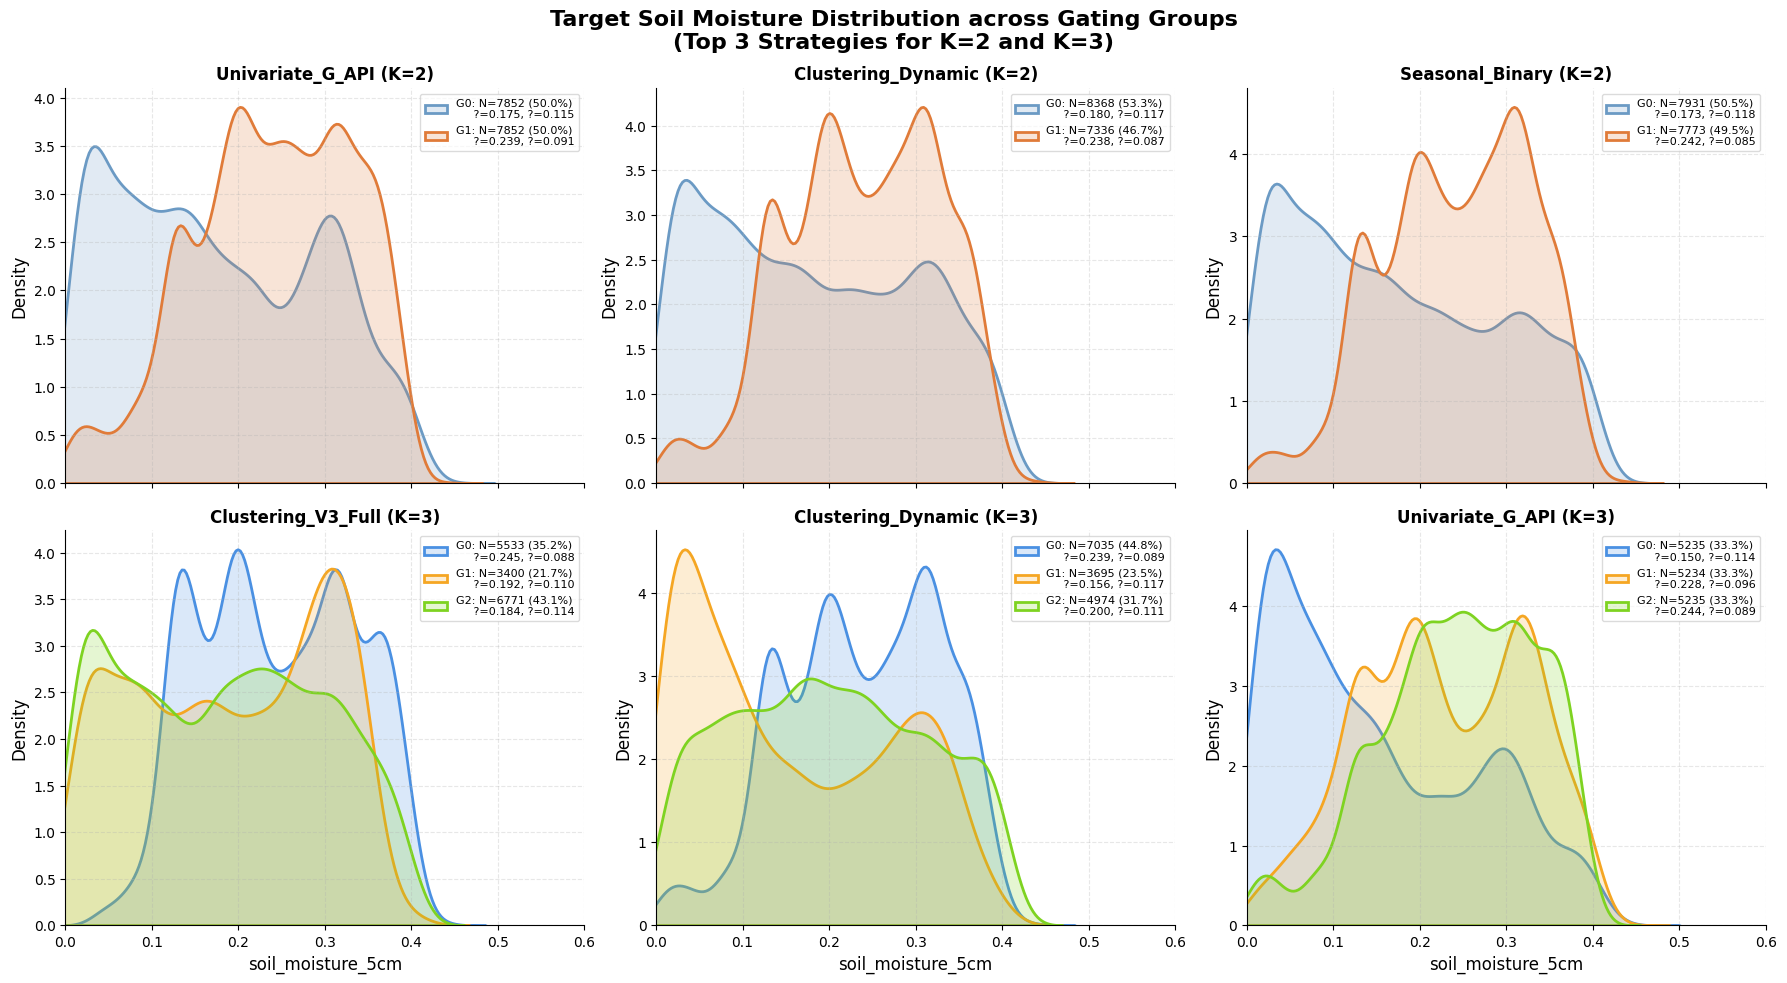

In [5]:
# Create a 2x3 subplot grid
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True)

# Define configurations to plot
plot_configs = [
    # Row 0: K=2
    {"idx": (0, 0), "res": gating_results[0], "palette": PALETTE_K2},
    {"idx": (0, 1), "res": gating_results[1], "palette": PALETTE_K2},
    {"idx": (0, 2), "res": gating_results[2], "palette": PALETTE_K2},
    # Row 1: K=3
    {"idx": (1, 0), "res": gating_results[3], "palette": PALETTE_K3},
    {"idx": (1, 1), "res": gating_results[4], "palette": PALETTE_K3},
    {"idx": (1, 2), "res": gating_results[5], "palette": PALETTE_K3}
]

for cfg in plot_configs:
    ax = axes[cfg["idx"]]
    res = cfg["res"]
    labels = res["labels"]
    palette = cfg["palette"]
    
    unique_labels = sorted(np.unique(labels))
    for g in unique_labels:
        mask = (labels == g)
        sub_target = train_df.loc[mask, 'soil_moisture_5cm']
        n_samples = len(sub_target)
        pct = n_samples / len(train_df) * 100
        mean_sm = sub_target.mean()
        std_sm = sub_target.std()
        
        sns.kdeplot(
            sub_target, 
            ax=ax, 
            label=f"G{g}: N={n_samples} ({pct:.1f}%)\n     ?={mean_sm:.3f}, ?={std_sm:.3f}", 
            fill=True, 
            alpha=0.20, 
            color=palette[g],
            linewidth=2
        )
        
    ax.set_title(f"{res['strategy']} (K={res['K']})", fontweight="bold", fontsize=12)
    ax.set_xlabel("soil_moisture_5cm" if cfg["idx"][0] == 1 else "")
    ax.legend(fontsize=8, loc="upper right", framealpha=0.7)
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_xlim(0, 0.6)

plt.suptitle("Target Soil Moisture Distribution across Gating Groups\n(Top 3 Strategies for K=2 and K=3)", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("gating_target_distributions_grid.png", dpi=300)
plt.show()

## 6. Visualization 2: Feature-Target Correlation Drift Heatmaps

We plot a grid of heatmaps showing feature-target correlation values for the top 20 globally correlated features across all groups for each strategy. This shows how feature sensitivities shift between the gating regimes.

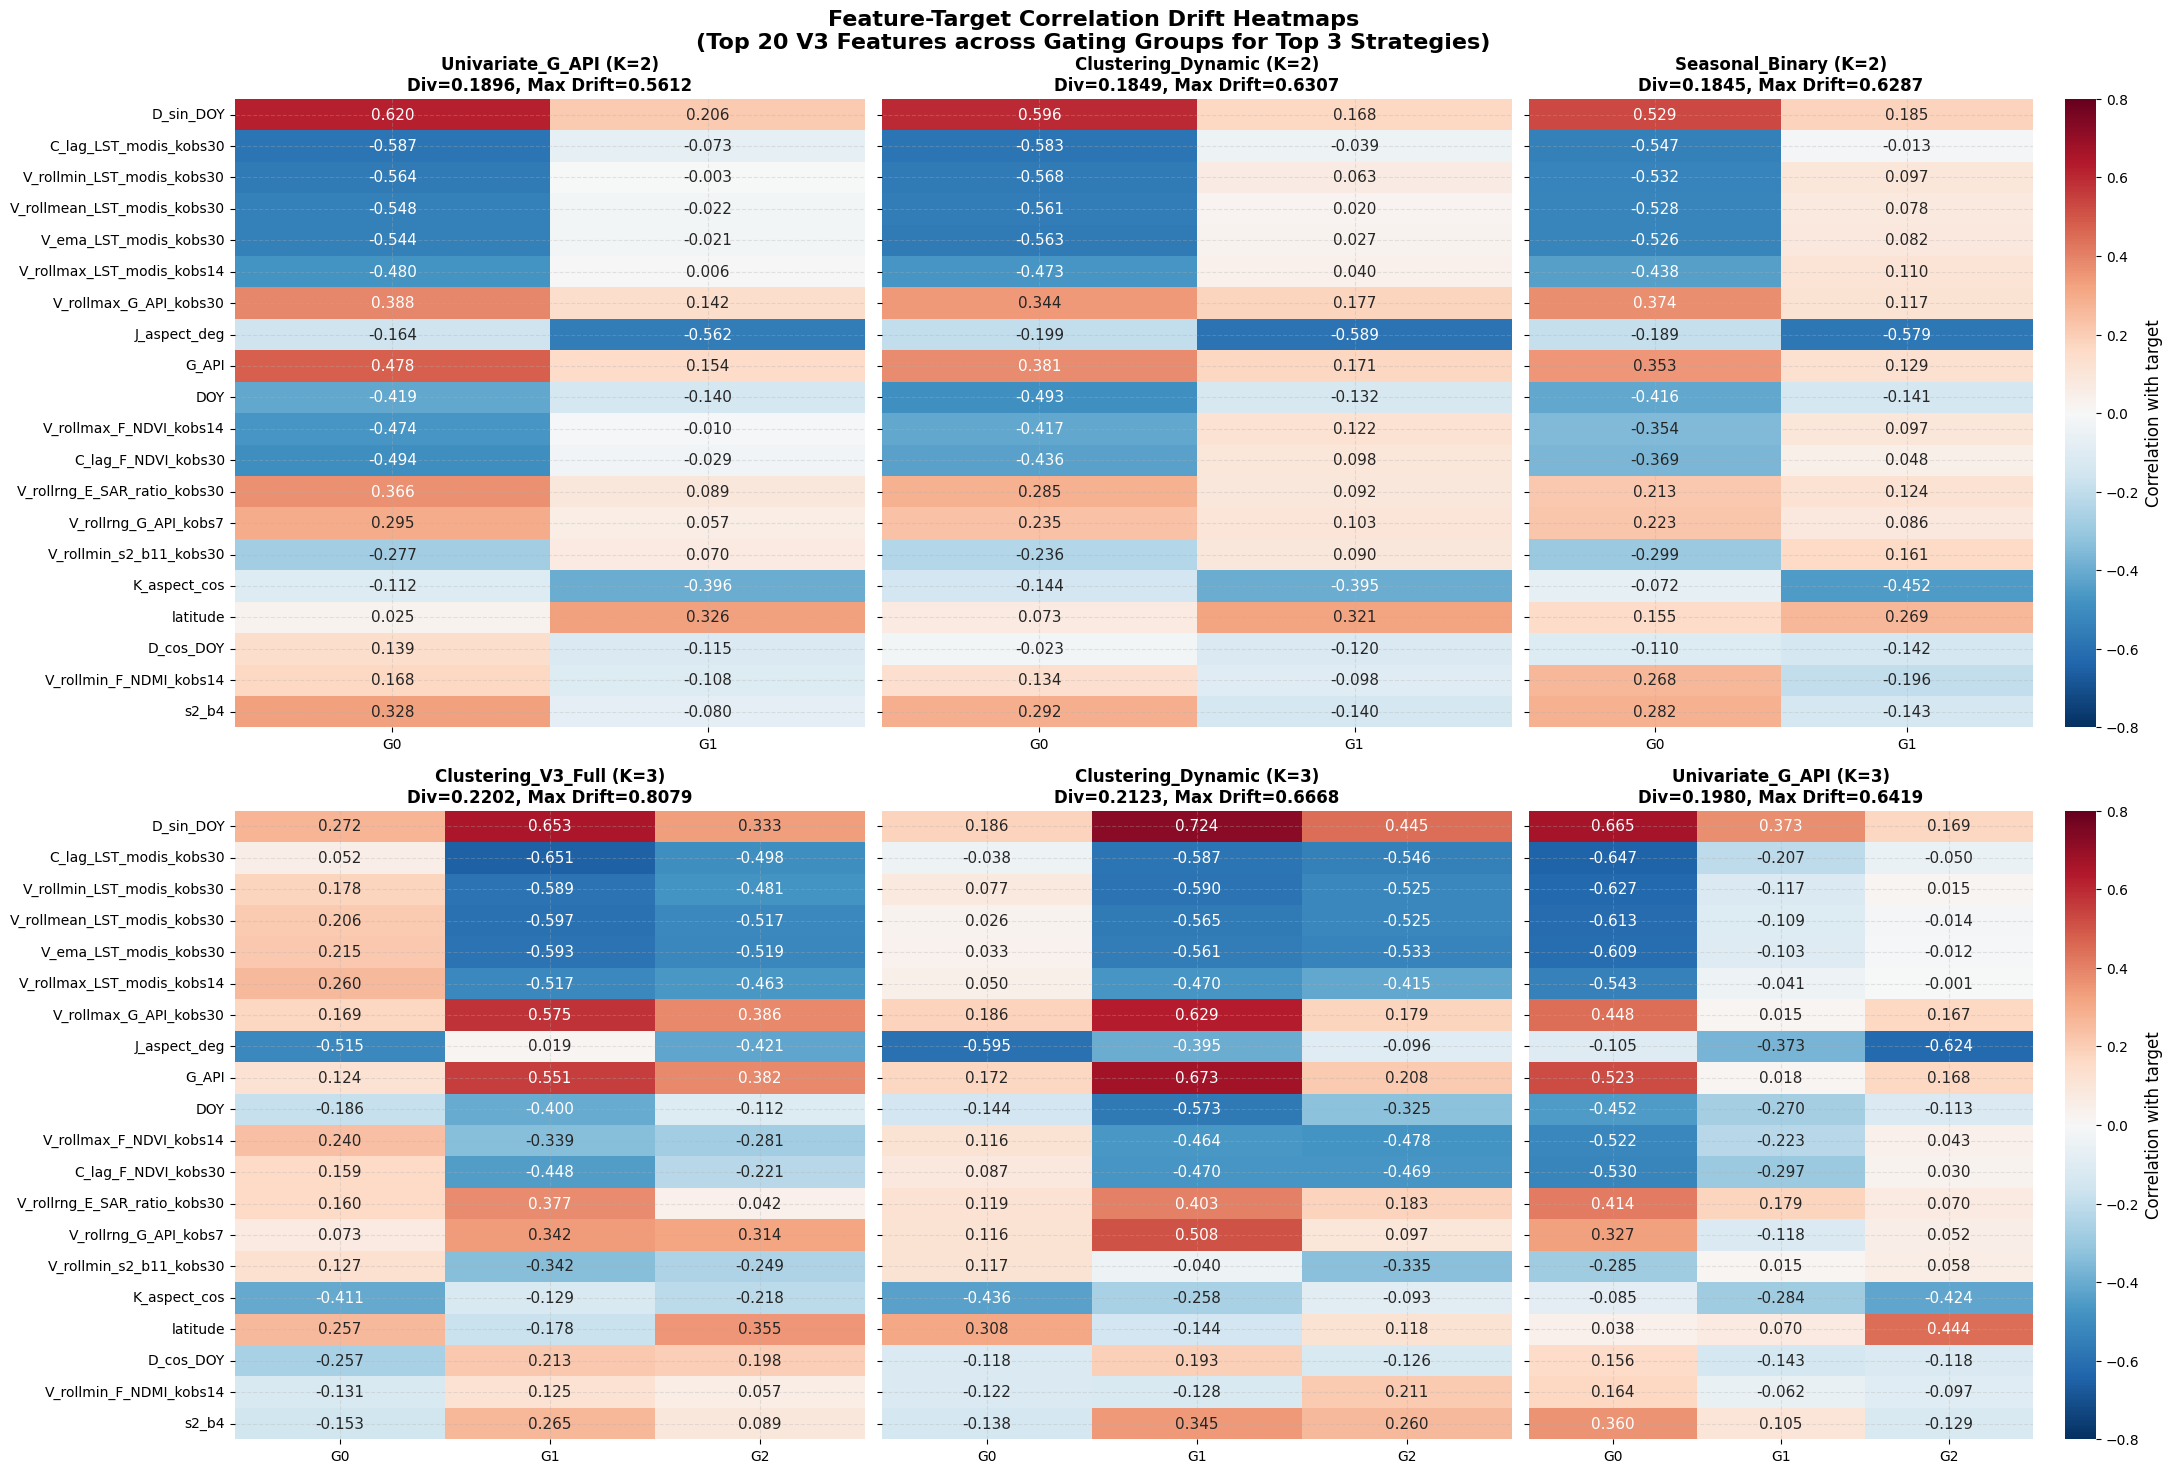

In [6]:
# Create a 2x3 subplot grid
fig, axes = plt.subplots(2, 3, figsize=(22, 15), sharey=True)

# Define configurations to plot
heatmap_configs = [
    # Row 0: K=2
    {"idx": (0, 0), "res": gating_results[0]},
    {"idx": (0, 1), "res": gating_results[1]},
    {"idx": (0, 2), "res": gating_results[2]},
    # Row 1: K=3
    {"idx": (1, 0), "res": gating_results[3]},
    {"idx": (1, 1), "res": gating_results[4]},
    {"idx": (1, 2), "res": gating_results[5]}
]

for cfg in heatmap_configs:
    ax = axes[cfg["idx"]]
    res = cfg["res"]
    top_feats = res["top_features"]
    corr_matrix_sub = res["corr_matrix"].loc[top_feats]
    
    # Standardize column headers to reflect Group IDs
    corr_matrix_sub.columns = [f"G{c}" for c in corr_matrix_sub.columns]
    
    # Plot heatmap
    sns.heatmap(
        corr_matrix_sub, 
        annot=True, 
        fmt=".3f", 
        cmap=PALETTE_DIVERGING, 
        vmin=-0.8, 
        vmax=0.8, 
        center=0.0, 
        ax=ax,
        cbar=(cfg["idx"] == (0, 2) or cfg["idx"] == (1, 2)), # Show cbar only on right plots
        cbar_kws={'label': 'Correlation with target'} if (cfg["idx"] == (0, 2) or cfg["idx"] == (1, 2)) else None
    )
    
    ax.set_title(f"{res['strategy']} (K={res['K']})\nDiv={res['div_top20']:.4f}, Max Drift={res['max_drift']:.4f}", fontweight="bold", fontsize=12)
    ax.tick_params(axis='x', rotation=0)

plt.suptitle("Feature-Target Correlation Drift Heatmaps\n(Top 20 V3 Features across Gating Groups for Top 3 Strategies)", fontsize=16, fontweight="bold", y=0.98)
plt.tight_layout()
plt.savefig("gating_correlation_drift_grid.png", dpi=300)
plt.show()

## 7. Visualization 3: Feature Space Separation

We analyze how the unsupervised cluster-based strategies separate observations in their feature spaces.
- For **`Clustering_Dynamic` (K=3)**, we plot a pairwise feature scatter matrix of the input features: SMAP, API, and LST.
- For **`Clustering_V3_Full` (K=3)**, we project the 47-dimensional feature space down to 2 principal components using PCA and plot the clusters in this reduced space, displaying the top loading features for physical interpretation.

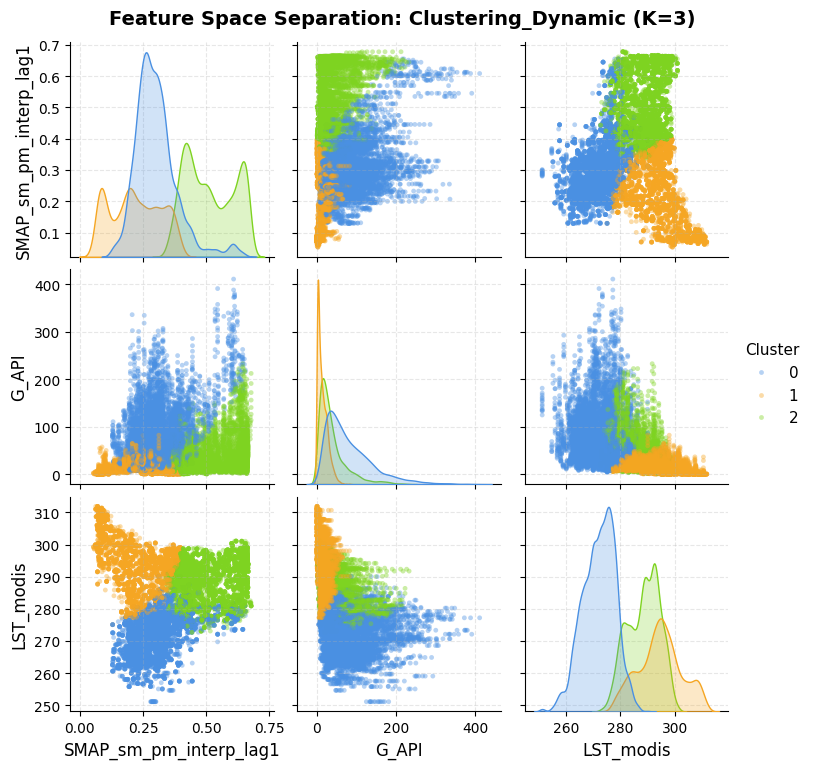

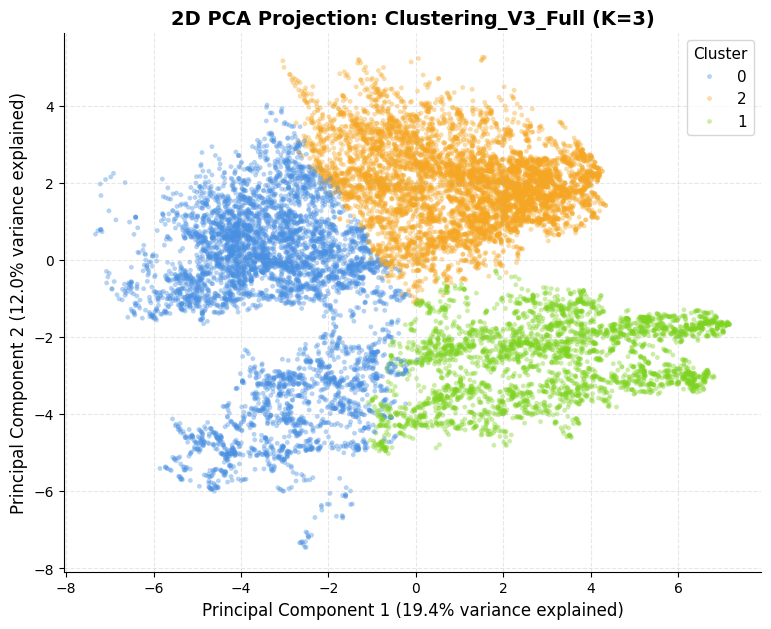

=== Top Loading Features on PC1 ===
V_ema_LST_modis_kobs30         0.318108
V_rollmean_LST_modis_kobs30    0.317394
V_rollmin_LST_modis_kobs30     0.308432
V_rollmax_LST_modis_kobs14     0.308189
C_lag_LST_modis_kobs30         0.300923
Name: PC1, dtype: float64

=== Top Loading Features on PC2 ===
J_bio_bio15                0.347306
J_bio_bio16                0.315920
J_bio_bio19                0.312701
J_lc_code                  0.289313
V_rollmax_F_NDVI_kobs14    0.287858
Name: PC2, dtype: float64


In [7]:
# 1. Pairplot for Clustering_Dynamic (K=3)
cols_dyn = ["SMAP_sm_pm_interp_lag1", "G_API", "LST_modis"]
df_dyn_plot = train_df[cols_dyn].copy()
df_dyn_plot = df_dyn_plot.fillna(df_dyn_plot.mean())
df_dyn_plot["Cluster"] = get_labels_for_strategy(train_df, "Clustering_Dynamic", 3)
df_dyn_plot["Cluster"] = df_dyn_plot["Cluster"].astype(str)

g = sns.pairplot(
    df_dyn_plot, 
    hue="Cluster", 
    palette=PALETTE_K3,
    diag_kind="kde",
    plot_kws={"alpha": 0.4, "s": 12, "edgecolor": "none"}
)
g.fig.suptitle("Feature Space Separation: Clustering_Dynamic (K=3)", y=1.02, fontsize=14, fontweight="bold")
g.savefig("clustering_dynamic_k3_pairplot.png", dpi=300)
plt.show()

# 2. PCA Projection for Clustering_V3_Full (K=3)
X_v3 = prepare_clustering_data(train_df, OVERALL_SELECTED_FEATURES_V3)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_v3)

df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
df_pca["Cluster"] = get_labels_for_strategy(train_df, "Clustering_V3_Full", 3)
df_pca["Cluster"] = df_pca["Cluster"].astype(str)

fig, ax = plt.subplots(figsize=(9, 7))
sns.scatterplot(
    data=df_pca,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette=PALETTE_K3,
    alpha=0.4,
    edgecolor="none",
    s=12,
    ax=ax
)

explained_variance = pca.explained_variance_ratio_
ax.set_xlabel(f"Principal Component 1 ({explained_variance[0]*100:.1f}% variance explained)")
ax.set_ylabel(f"Principal Component 2 ({explained_variance[1]*100:.1f}% variance explained)")
ax.set_title("2D PCA Projection: Clustering_V3_Full (K=3)", fontsize=14, fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(title="Cluster")
plt.savefig("clustering_v3_full_k3_pca.png", dpi=300)
plt.show()

# Calculate PCA loadings
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=OVERALL_SELECTED_FEATURES_V3
)
print("=== Top Loading Features on PC1 ===")
print(loadings["PC1"].abs().sort_values(ascending=False).head(5))
print("\n=== Top Loading Features on PC2 ===")
print(loadings["PC2"].abs().sort_values(ascending=False).head(5))

## 8. Visualization 4: Geographical Distribution of Gating Groups

We visualize the spatial distribution of the gating groups across Washington state. Since some strategies are dynamic (the label for a station can change over time), we aggregate the labels per station and identify the **dominant group** (the mode) for each station. We then map the station coordinates (`latitude` and `longitude`) colored by their dominant group.

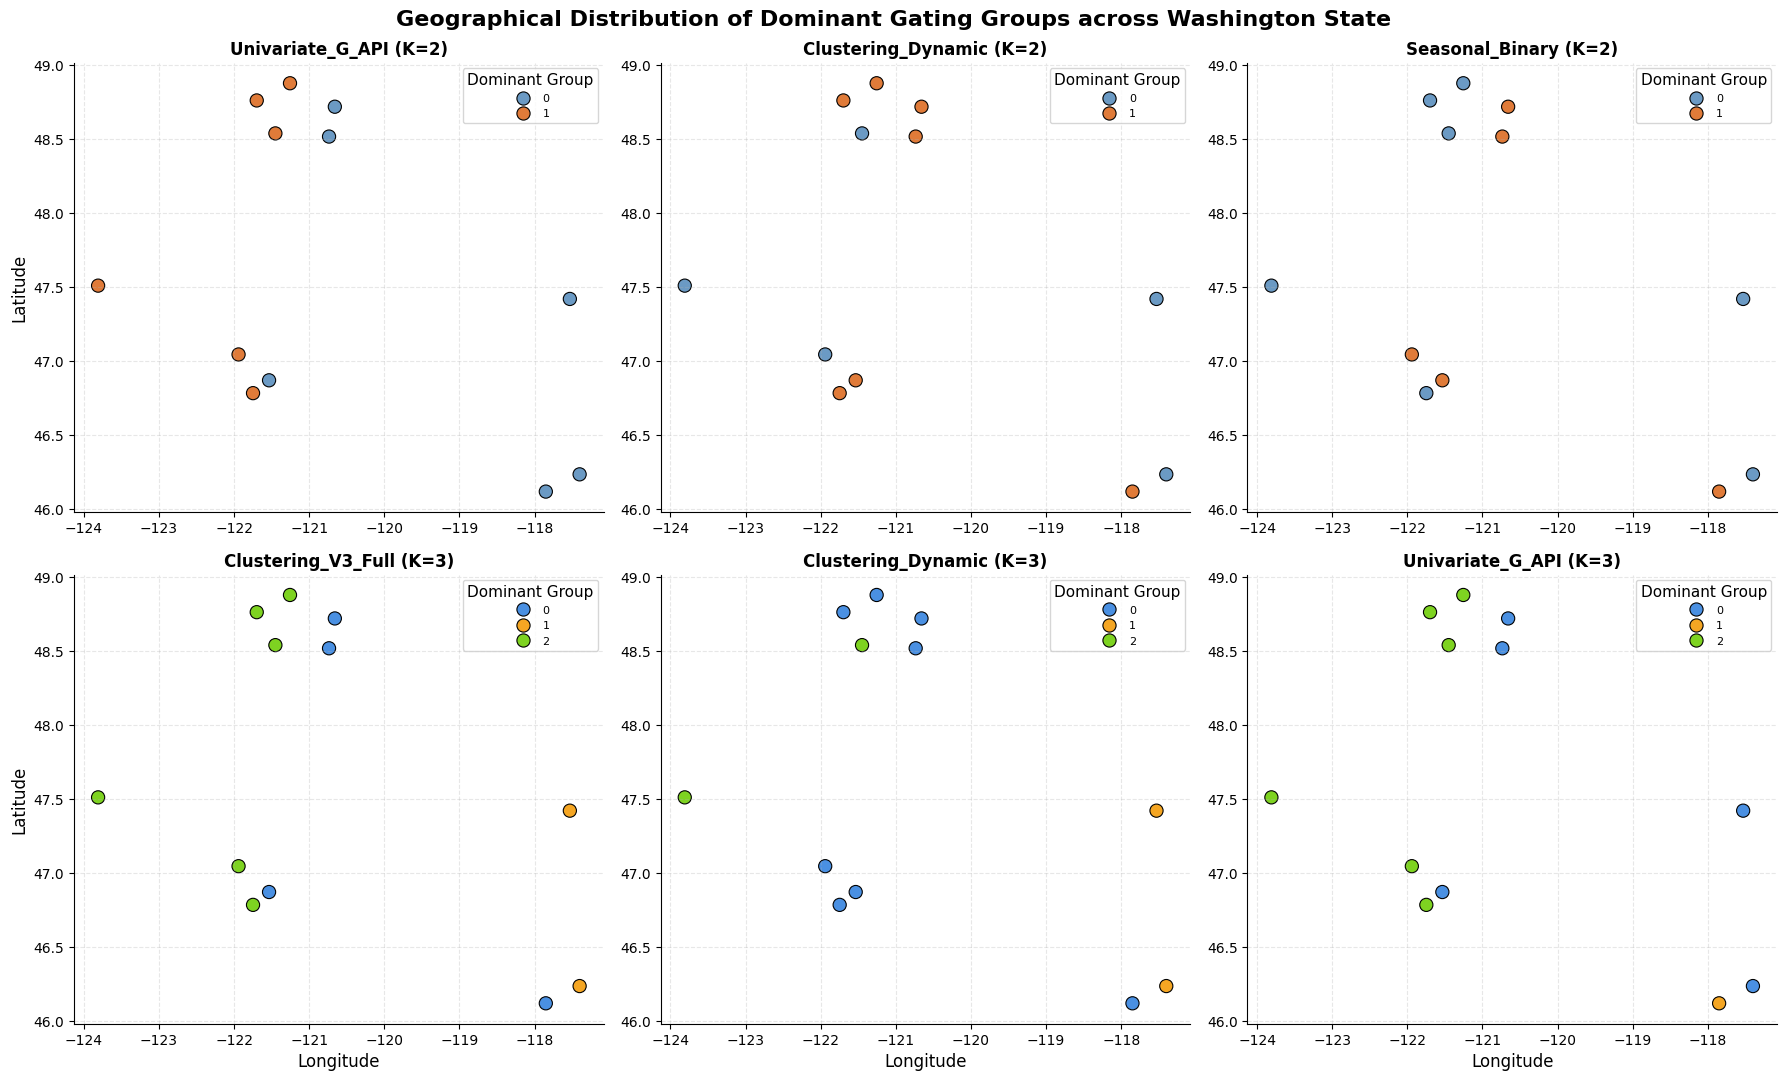

In [8]:
def plot_geographic_stations(df, strategy_name, K, palette, ax):
    # Retrieve labels for the strategy
    labels = get_labels_for_strategy(df, strategy_name, K)
    
    # Create a temp DataFrame with station coordinates and labels
    df_temp = df[['station_id', 'longitude', 'latitude']].copy()
    df_temp['Group'] = labels
    
    # Group by station_id and find the mode (dominant group)
    station_gps = df_temp.groupby('station_id').agg({
        'longitude': 'first',
        'latitude': 'first',
        'Group': lambda x: x.mode()[0] if len(x) > 0 else 0
    }).reset_index()
    
    # Plot stations on coordinate axes
    sns.scatterplot(
        data=station_gps,
        x='longitude',
        y='latitude',
        hue='Group',
        palette=palette,
        s=90,
        edgecolor='black',
        linewidth=0.8,
        ax=ax,
        legend='full'
    )
    
    ax.set_title(f"{strategy_name} (K={K})", fontweight='bold', fontsize=12)
    ax.set_xlabel("Longitude" if ax.get_subplotspec().is_last_row() else "")
    ax.set_ylabel("Latitude" if ax.get_subplotspec().is_first_col() else "")
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(title="Dominant Group", fontsize=8, loc='best')

# Create a 2x3 subplot grid for geographic maps
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

map_configs = [
    # Row 0: K=2
    {"idx": (0, 0), "name": "Univariate_G_API", "K": 2, "palette": PALETTE_K2},
    {"idx": (0, 1), "name": "Clustering_Dynamic", "K": 2, "palette": PALETTE_K2},
    {"idx": (0, 2), "name": "Seasonal_Binary", "K": 2, "palette": PALETTE_K2},
    # Row 1: K=3
    {"idx": (1, 0), "name": "Clustering_V3_Full", "K": 3, "palette": PALETTE_K3},
    {"idx": (1, 1), "name": "Clustering_Dynamic", "K": 3, "palette": PALETTE_K3},
    {"idx": (1, 2), "name": "Univariate_G_API", "K": 3, "palette": PALETTE_K3}
]

for cfg in map_configs:
    ax = axes[cfg["idx"]]
    plot_geographic_stations(train_df, cfg["name"], cfg["K"], cfg["palette"], ax)

plt.suptitle("Geographical Distribution of Dominant Gating Groups across Washington State", fontsize=16, fontweight="bold", y=0.98)
plt.tight_layout()
plt.savefig("gating_geographic_distribution.png", dpi=300)
plt.show()

## 9. Advanced Clustering Separation Diagnostics

We perform detailed evaluations of how well the data observations are separated by our clustering-based gating strategies.
1. **Quality Metrics vs. K**: We plot the Elbow Curve (Inertia) and Average Silhouette Score for $K \in [2, 6]$ to justify our choice of cluster numbers.
2. **Silhouette Profile Plots**: We plot silhouette coefficient distributions for $K=2$ and $K=3$ for `Clustering_V3_Full` to evaluate cluster cohesion.
3. **t-SNE 2D Projection**: We project the high-dimensional feature space to a 2D plane using t-SNE to capture non-linear cluster boundaries.
4. **Cluster Centroid Distance Distributions**: We calculate the ratio of a point's distance to its own centroid vs. the nearest other centroid. This measures whether points are tightly grouped or fuzzy at the boundaries.

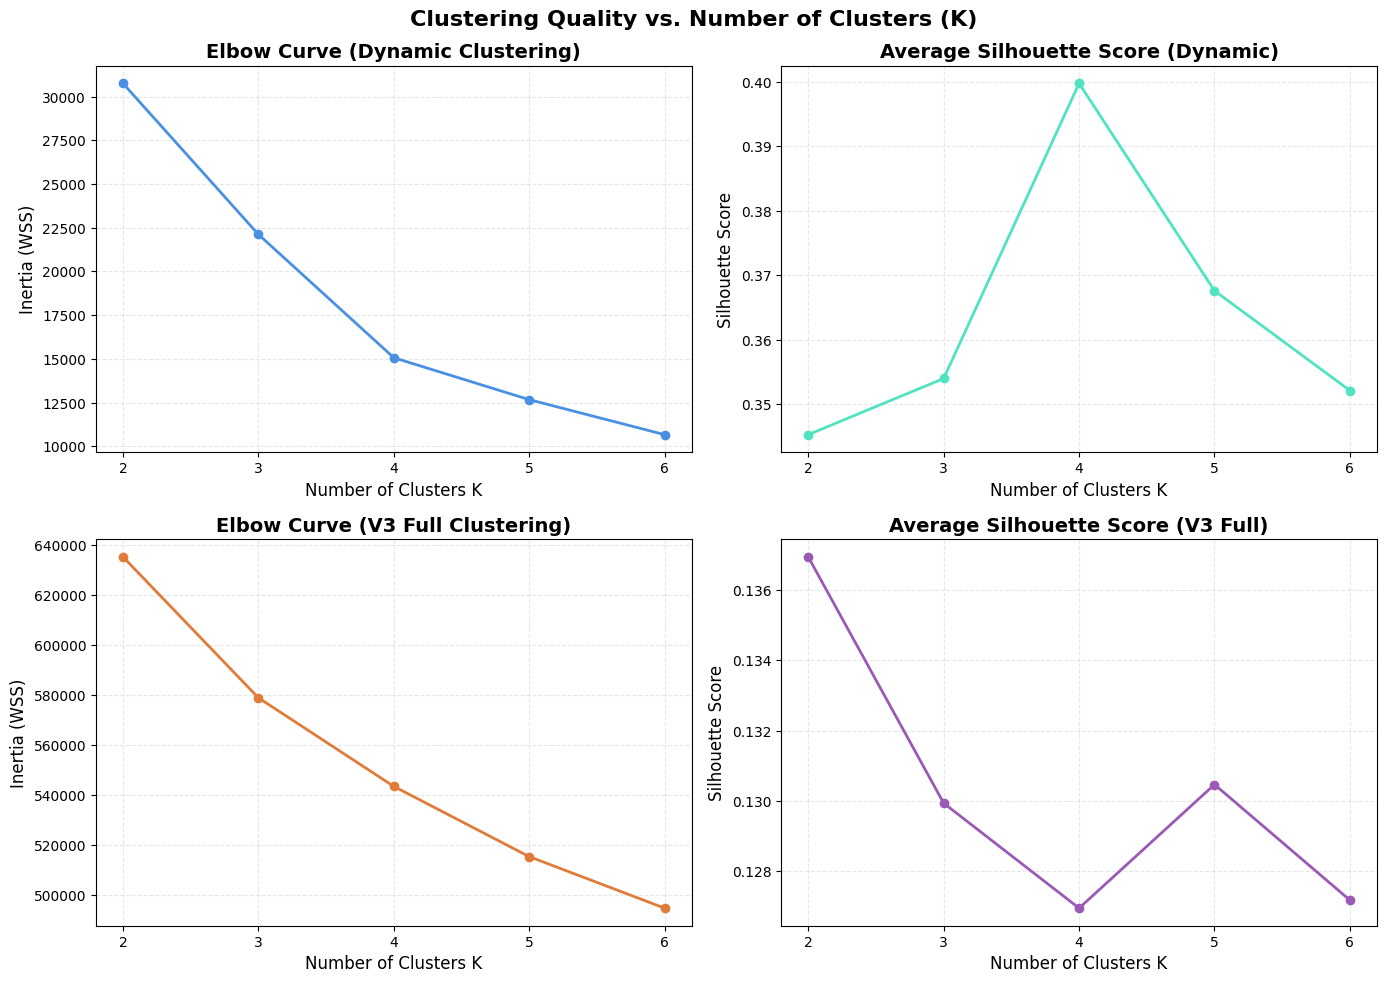

In [9]:
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.manifold import TSNE

# 1. Elbow & Silhouette Analysis vs K
K_range = [2, 3, 4, 5, 6]

# Prepare data
X_dyn = prepare_clustering_data(train_df, ["SMAP_sm_pm_interp_lag1", "G_API", "LST_modis"])
X_v3 = prepare_clustering_data(train_df, OVERALL_SELECTED_FEATURES_V3)

# For silhouette speed, sample 3000 indices
np.random.seed(42)
sample_idx = np.random.choice(len(train_df), size=min(3000, len(train_df)), replace=False)

metrics = {
    "Dynamic": {"inertia": [], "silhouette": []}, 
    "V3_Full": {"inertia": [], "silhouette": []}
}

for K in K_range:
    # Dynamic
    km_dyn = KMeans(n_clusters=K, random_state=42, n_init=10)
    lbl_dyn = km_dyn.fit_predict(X_dyn)
    metrics["Dynamic"]["inertia"].append(km_dyn.inertia_)
    metrics["Dynamic"]["silhouette"].append(silhouette_score(X_dyn[sample_idx], lbl_dyn[sample_idx]))
    
    # V3 Full
    km_v3 = KMeans(n_clusters=K, random_state=42, n_init=10)
    lbl_v3 = km_v3.fit_predict(X_v3)
    metrics["V3_Full"]["inertia"].append(km_v3.inertia_)
    metrics["V3_Full"]["silhouette"].append(silhouette_score(X_v3[sample_idx], lbl_v3[sample_idx]))

# Plot Metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Dynamic curves
axes[0, 0].plot(K_range, metrics["Dynamic"]["inertia"], marker='o', color="#4A90E2", linewidth=2)
axes[0, 0].set_title("Elbow Curve (Dynamic Clustering)", fontweight="bold")
axes[0, 0].set_xlabel("Number of Clusters K")
axes[0, 0].set_ylabel("Inertia (WSS)")
axes[0, 0].set_xticks(K_range)

axes[0, 1].plot(K_range, metrics["Dynamic"]["silhouette"], marker='o', color="#50E3C2", linewidth=2)
axes[0, 1].set_title("Average Silhouette Score (Dynamic)", fontweight="bold")
axes[0, 1].set_xlabel("Number of Clusters K")
axes[0, 1].set_ylabel("Silhouette Score")
axes[0, 1].set_xticks(K_range)

# V3 Full curves
axes[1, 0].plot(K_range, metrics["V3_Full"]["inertia"], marker='o', color="#E07B39", linewidth=2)
axes[1, 0].set_title("Elbow Curve (V3 Full Clustering)", fontweight="bold")
axes[1, 0].set_xlabel("Number of Clusters K")
axes[1, 0].set_ylabel("Inertia (WSS)")
axes[1, 0].set_xticks(K_range)

axes[1, 1].plot(K_range, metrics["V3_Full"]["silhouette"], marker='o', color="#9B59B6", linewidth=2)
axes[1, 1].set_title("Average Silhouette Score (V3 Full)", fontweight="bold")
axes[1, 1].set_xlabel("Number of Clusters K")
axes[1, 1].set_ylabel("Silhouette Score")
axes[1, 1].set_xticks(K_range)

plt.suptitle("Clustering Quality vs. Number of Clusters (K)", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("clustering_metrics_comparison.png", dpi=300)
plt.show()

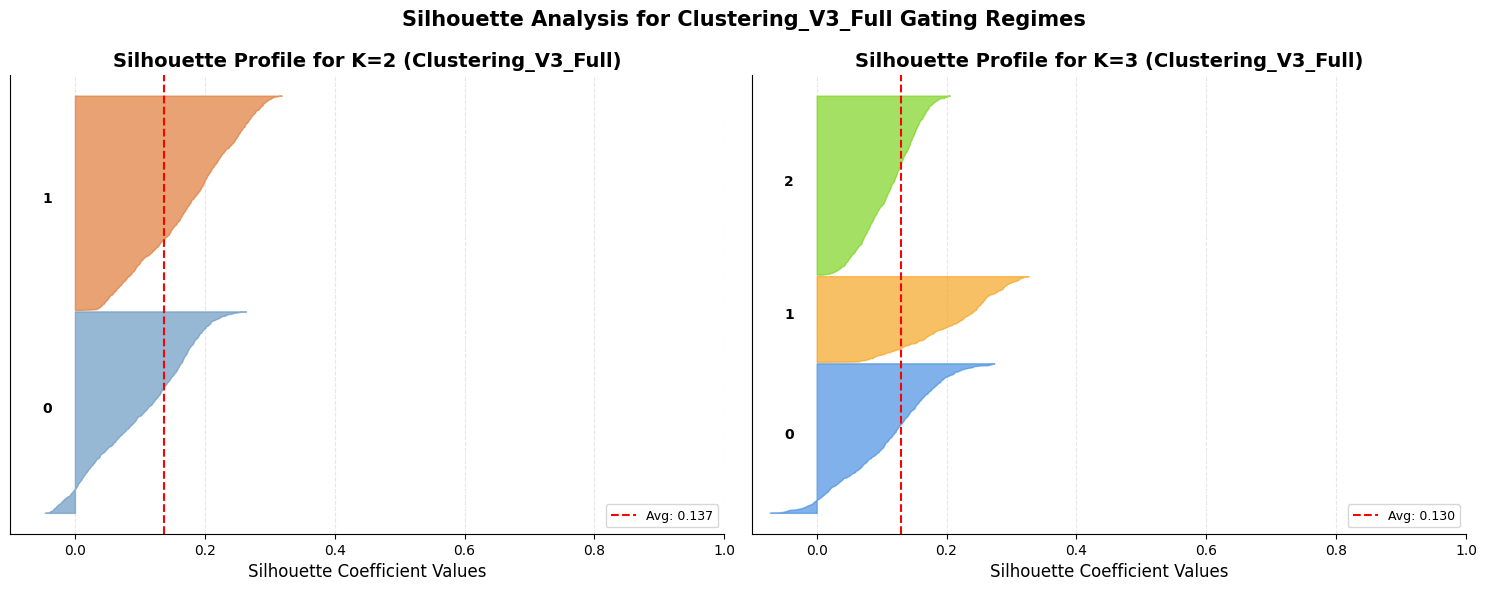

In [10]:
# 2. Silhouette Profile Plots for Clustering_V3_Full (K=2 and K=3)
def plot_silhouette_profile(X, labels, K, ax):
    np.random.seed(42)
    sample_idx = np.random.choice(len(X), size=min(3000, len(X)), replace=False)
    X_sub = X[sample_idx]
    labels_sub = labels[sample_idx]
    
    avg_score = silhouette_score(X_sub, labels_sub)
    sample_values = silhouette_samples(X_sub, labels_sub)
    
    y_lower = 10
    for i in range(K):
        ith_cluster_values = sample_values[labels_sub == i]
        ith_cluster_values.sort()
        
        size_cluster_i = ith_cluster_values.shape[0]
        y_upper = y_lower + size_cluster_i
        
        color = PALETTE_K3[i] if K == 3 else PALETTE_K2[i]
        ax.fill_betweenx(np.arange(y_lower, y_upper),
                          0, ith_cluster_values,
                          facecolor=color, edgecolor=color, alpha=0.7)
        
        ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i), fontsize=10, fontweight="bold")
        y_lower = y_upper + 10
        
    ax.set_title(f"Silhouette Profile (K={K})", fontweight="bold", fontsize=12)
    ax.set_xlabel("Silhouette Coefficient Values")
    ax.axvline(x=avg_score, color="red", linestyle="--", linewidth=1.5, label=f"Avg: {avg_score:.3f}")
    ax.set_yticks([])
    ax.set_xlim([-0.1, 1.0])
    ax.legend(loc="lower right", fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

labels_v3_k2 = get_labels_for_strategy(train_df, "Clustering_V3_Full", 2)
labels_v3_k3 = get_labels_for_strategy(train_df, "Clustering_V3_Full", 3)

plot_silhouette_profile(X_v3, labels_v3_k2, 2, axes[0])
axes[0].set_title("Silhouette Profile for K=2 (Clustering_V3_Full)", fontweight="bold")

plot_silhouette_profile(X_v3, labels_v3_k3, 3, axes[1])
axes[1].set_title("Silhouette Profile for K=3 (Clustering_V3_Full)", fontweight="bold")

plt.suptitle("Silhouette Analysis for Clustering_V3_Full Gating Regimes", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("clustering_silhouette_profiles.png", dpi=300)
plt.show()

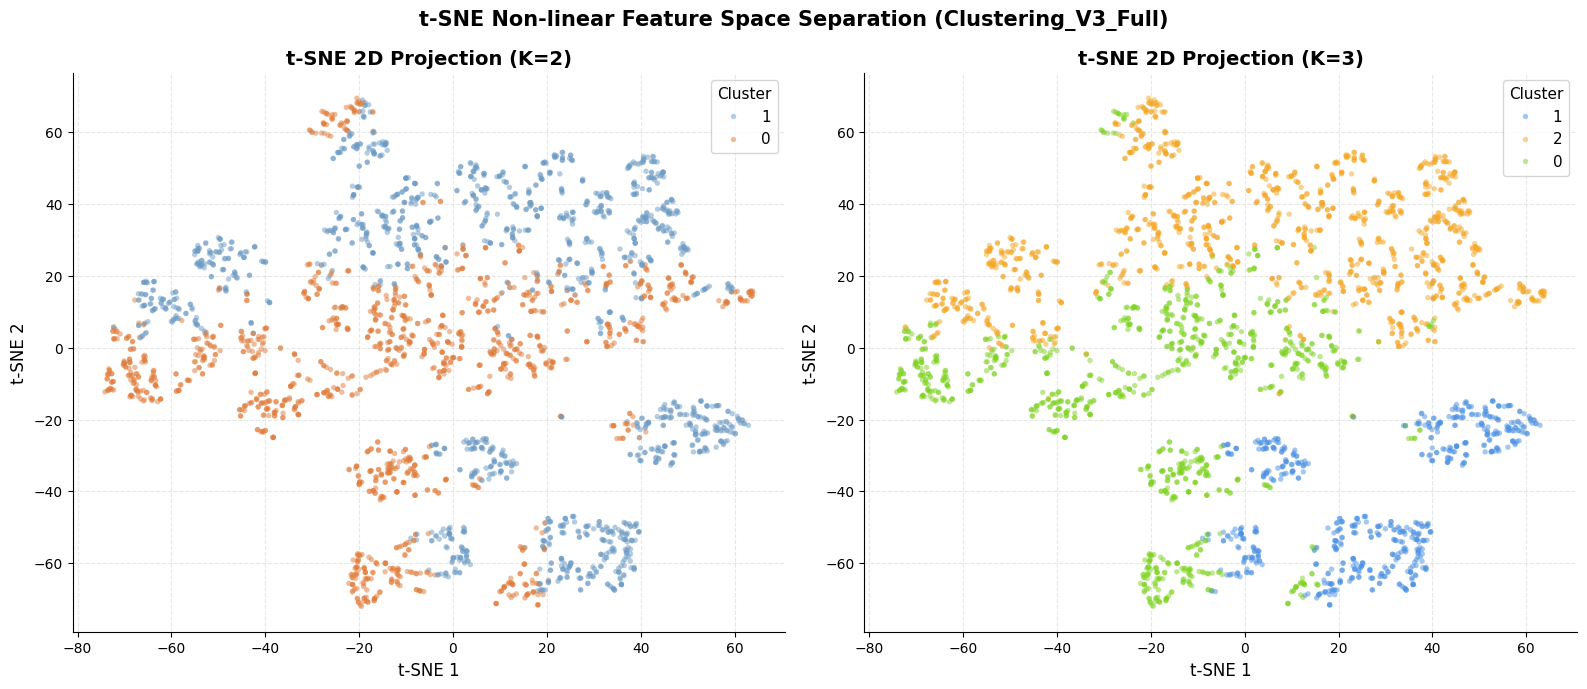

In [11]:
# 3. t-SNE 2D Projections for Clustering_V3_Full (K=2 and K=3)
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
X_v3_tsne = tsne.fit_transform(X_v3[sample_idx])

df_tsne = pd.DataFrame(X_v3_tsne, columns=["t-SNE 1", "t-SNE 2"])
df_tsne["Cluster K=2"] = labels_v3_k2[sample_idx].astype(str)
df_tsne["Cluster K=3"] = labels_v3_k3[sample_idx].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# K=2 scatter
sns.scatterplot(
    data=df_tsne,
    x="t-SNE 1",
    y="t-SNE 2",
    hue="Cluster K=2",
    palette=PALETTE_K2,
    alpha=0.5,
    edgecolor="none",
    s=15,
    ax=axes[0]
)
axes[0].set_title("t-SNE 2D Projection (K=2)", fontweight="bold")
axes[0].spines[["top", "right"]].set_visible(False)
axes[0].legend(title="Cluster")

# K=3 scatter
sns.scatterplot(
    data=df_tsne,
    x="t-SNE 1",
    y="t-SNE 2",
    hue="Cluster K=3",
    palette=PALETTE_K3,
    alpha=0.5,
    edgecolor="none",
    s=15,
    ax=axes[1]
)
axes[1].set_title("t-SNE 2D Projection (K=3)", fontweight="bold")
axes[1].spines[["top", "right"]].set_visible(False)
axes[1].legend(title="Cluster")

plt.suptitle("t-SNE Non-linear Feature Space Separation (Clustering_V3_Full)", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("clustering_tsne_projection.png", dpi=300)
plt.show()


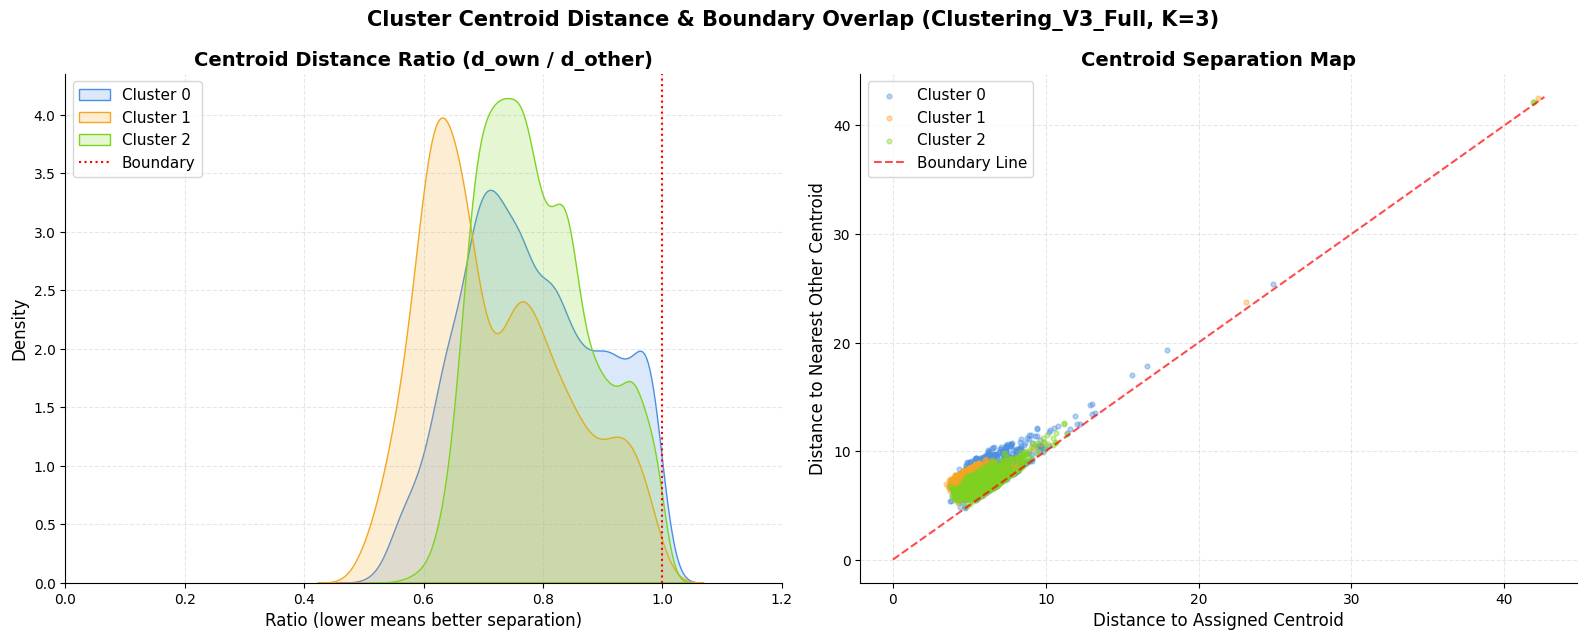

In [12]:
# 4. Cluster Centroid Distance Distributions for Clustering_V3_Full (K=3)
kmeans_v3_k3 = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_v3_k3.fit(X_v3)
centroids = kmeans_v3_k3.cluster_centers_

# Compute distances to centroids
dists = []
for c in centroids:
    dist_c = np.linalg.norm(X_v3 - c, axis=1)
    dists.append(dist_c)
dists = np.column_stack(dists)

assigned_clusters = kmeans_v3_k3.labels_
dist_to_own = dists[np.arange(len(X_v3)), assigned_clusters]

dists_temp = dists.copy()
dists_temp[np.arange(len(X_v3)), assigned_clusters] = np.inf
dist_to_nearest_other = dists_temp.min(axis=1)

# Distance ratio (closer to 0 is better separation)
dist_ratio = dist_to_own / dist_to_nearest_other

fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))

# Plot Ratio KDE
ax_ratio = axes[0]
for i in range(3):
    mask = (assigned_clusters == i)
    sns.kdeplot(dist_ratio[mask], ax=ax_ratio, label=f"Cluster {i}", color=PALETTE_K3[i], fill=True, alpha=0.2)
ax_ratio.axvline(x=1.0, color="red", linestyle=":", linewidth=1.5, label="Boundary")
ax_ratio.set_title("Centroid Distance Ratio (d_own / d_other)", fontweight="bold")
ax_ratio.set_xlabel("Ratio (lower means better separation)")
ax_ratio.legend()
ax_ratio.spines[["top", "right"]].set_visible(False)
ax_ratio.set_xlim(0, 1.2)

# Plot Centroid Separation Map
ax_scatter = axes[1]
for i in range(3):
    mask = (assigned_clusters == i)
    sub_mask = np.random.choice(np.where(mask)[0], size=min(1000, mask.sum()), replace=False)
    ax_scatter.scatter(
        dist_to_own[sub_mask], 
        dist_to_nearest_other[sub_mask], 
        color=PALETTE_K3[i], 
        alpha=0.4, 
        s=12, 
        label=f"Cluster {i}"
    )
lims = [0, max(dist_to_own.max(), dist_to_nearest_other.max())]
ax_scatter.plot(lims, lims, 'r--', alpha=0.7, label='Boundary Line')
ax_scatter.set_title("Centroid Separation Map", fontweight="bold")
ax_scatter.set_xlabel("Distance to Assigned Centroid")
ax_scatter.set_ylabel("Distance to Nearest Other Centroid")
ax_scatter.legend()
ax_scatter.spines[["top", "right"]].set_visible(False)

plt.suptitle("Cluster Centroid Distance & Boundary Overlap (Clustering_V3_Full, K=3)", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("clustering_centroid_distances.png", dpi=300)
plt.show()